In [1]:
import pandas as pd 

class DataSet:
   def  __init__(self):
     pass
   def dataload(self,path):
     df = pd.read_csv(path).sample(200000,random_state = 42)
     return df


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



class DataOverviewer:
    def __init__(self):
     pass 
    def datasetOverview(self,df):
        print (" \033[1mDataset Overview\033[0m:\n")
        print(df.head(10))
        print("Number of rows and columns of dataset are :", df.shape)
        df.info()
        

In [3]:
class AMLExplorer:
    def __init__(self, df, label_col = "Is_laundering"):
        self.df = df.copy()
        self.label_col = label_col

    def plot_class_distribution(self):
        tr_probs = self.df[self.label_col].value_counts(normalize = True)
        print(tr_probs)
        plt.figure(figsize=(6,4))
        tr_bars = plt.bar(tr_probs.index.astype(str), tr_probs.values)
        
        for i , bar in enumerate(tr_bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height*100:.1f}%",ha='center',va='bottom'
            )
        
        plt.xlabel("Transaction Class")
        plt.ylabel("Probability")
        plt.ylim(0,max(tr_probs.values) * 1.05)
        plt.title("Empirical Probability of Transaction Classes")
        plt.tight_layout()
        plt.show()
         

    def EDA_amount(self,amount_col = "Amount"):
        print(self.df[amount_col].isna().mean())
        print(self.df[amount_col].describe())

        print(self.df[amount_col].describe(percentiles = [0.5 , 0.9 , 0.95, 0.99 ,0.999]))

        sns.histplot(self.df[amount_col],bins = 100)
        plt.title("Raw Amount Distribution")
        plt.show()

        #Visualize again to see a sensible shape 
        self.df["Log_amount"] = np.log1p(self.df["Amount"])
        sns.histplot(self.df["Log_amount"],bins = 100)
        plt.title("Log-Transformed Amount Distribution")
        plt.show()

        #Comparison between the distribution of fraud and normal and see any meaning of Amount
        #Use a sample for plotting because of the million rows/transactions

        df_sample = self.df.sample(200_000,random_state = 42)
        sns.boxplot(
            x = "Is_laundering",
            y = "Log_amount",
            data = df_sample)

        plt.title("Log Amount vs Transaction Class (Boxplot)")
        plt.show()
       
        return self.df
        #Conditional Probability of Fraud Transaction based on the Amount group values
    def Prob_Change(self,amount_col = "Amount"):
        self.df["amount_decile"] = pd.qcut(df[amount_col],q = 10,duplicates = "drop")
        conditional_prob_class = self.df.groupby("amount_decile")["Is_laundering"].mean().mul(100)
        print(conditional_prob_class)

        return self.df
        



In [4]:
import pandas as pd
class DataFrame_Split:
    def __init__(self):
        pass
    #Pick a cut point with the quantile to separate the train_df from the test one
    def train_test_split(self,df):
        df["timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])
        df = df.sort_values("timestamp")
        split_time = df["timestamp"].quantile(0.8)
        train_df = df[df["timestamp"] <= split_time].copy()
        test_df = df[df["timestamp"] > split_time].copy()            
        return train_df,test_df

In [5]:
import numpy as np
class FeatureEngineering_1:
    def __init__(self):
        pass
    def new_features(self,train_df,test_df):
        for df in [train_df,test_df]:
            df["Log_Amount"] = np.log1p(df["Amount"])
            df["hour"] = df["timestamp"].dt.hour
            df["day_of_week"] = df["timestamp"].dt.weekday
            df["weekend"] = df["day_of_week"].isin([5,6]).astype(int)
        return train_df,test_df

In [6]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

class Encoder:
    def __init__(self,cat_cols):
        self.cat_cols = list(cat_cols)
        self.enc = OneHotEncoder(handle_unknown = "ignore",sparse_output= True )
        self.is_fitted = False
    def fit(self,df):
        self.enc.fit(df[self.cat_cols])
        self.is_fitted = True
        return self 
        
    def transform(self,df):
        if not self.is_fitted:
            raise RuntimeError("Call fit() first.")
            
        print("self.cat_cols:",self.cat_cols)
        print("Type of self.cat_cols",type(self.cat_cols))
        print("DataFrame dimensions for cat_col",df[self.cat_cols].shape)
        encoded = self.enc.transform(df[self.cat_cols])
        
        print("type(encoded):", type(encoded))
        print("encoded.shape BEFORE:", encoded.shape)

        if hasattr(encoded, "toarray"):
            encoded = encoded.toarray()

        print("encoded.shape AFTER:", encoded.shape)

        feature_names = self.enc.get_feature_names_out(self.cat_cols)
        print("len(feature_names):", len(feature_names))
        print("first few feature names:", feature_names[:10])
        
        encoded_df = pd.DataFrame(encoded,columns = feature_names,index = df.index)
        
        df_out = pd.concat([df.drop(columns = self.cat_cols),encoded_df],axis = 1)  

        return df_out


In [7]:
import pandas as pd

class FeatureEngineering_2:
    def __init__(self):
        pass

    def sendergrouping_eng(self,train_df):
        senderbehaviour = train_df.groupby("Sender_account").agg(

            sender_transaction_count=("Amount","count"),
            sender_mean_Amount = ("Amount","mean"),
            sender_std_Amount = ("Amount","std"),
            receiver_bank_loc_n = ("Receiver_bank_location","nunique")
        ).reset_index()
        senderbehaviour["sender_std_Amount"] = senderbehaviour["sender_std_Amount"].replace(0,1)
        senderbehaviour["sender_std_Amount"] = senderbehaviour["sender_std_Amount"].fillna(1)
        return senderbehaviour
    def merging(self,senderbehaviour,train_df):
        train_df = pd.merge(train_df,senderbehaviour,on = "Sender_account",how = "left") 
        return train_df

In [8]:
class TimeFeatures:
    def __init__(self):
        pass
    def burst_transactions(self,train_df,test_df):
        #We reduced the feature columns of the train_df,test_df for the purpose of rolling because of ram issues
        #By making a smaller train_df,test_df with the features of interest
        train_df_small = train_df[["Sender_account","timestamp","Amount"]].copy()
        test_df_small = test_df[["Sender_account","timestamp","Amount"]].copy()
        threshold = train_df_small["Amount"].quantile(0.2)
        train_df_small["is_small"] = (train_df_small["Amount"] <= threshold).astype("int8")
        test_df_small["is_small"] = (test_df_small["Amount"] <= threshold).astype("int8")
        train_df_small["train_or_test"] = "train"
        test_df_small["train_or_test"] = "test"
        combined_df = pd.concat([train_df_small,test_df_small],ignore_index = True)
        combined_df = combined_df.sort_values(["Sender_account","timestamp"])
        time_window = "10min"
        combined_df = combined_df.set_index("timestamp")
        groups = combined_df.groupby("Sender_account",group_keys = False)
        combined_df['burst_small_payments_every10min'] = groups["is_small"].rolling(time_window).sum().reset_index(level = 0 ,drop = True)
        combined_df['all_payments_every_10min'] = groups["is_small"].rolling(time_window).count().reset_index(level = 0 ,drop = True)
        combined_df['Small_payments_Percentage_every'] = combined_df['burst_small_payments_every10min'] / combined_df['all_payments_every_10min']
        combined_df = combined_df.reset_index()
        train_feats = combined_df[combined_df["train_or_test"] == "train"][["Sender_account","timestamp","burst_small_payments_every10min","all_payments_every_10min",
        "Small_payments_Percentage_every"]]
        test_feats = combined_df[combined_df["train_or_test"] == "test"][["Sender_account","timestamp","burst_small_payments_every10min","all_payments_every_10min",
        "Small_payments_Percentage_every"]]
        train_df = train_df.merge(train_feats, on=["Sender_account", "timestamp"], how="left")
        test_df = test_df.merge(test_feats, on=["Sender_account", "timestamp"], how="left")
        return train_df,test_df


In [9]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score,roc_curve,confusion_matrix
class AML_Model:
    def __init__(self,contamination):
            self.model = IsolationForest(n_estimators=200,
            contamination=contamination,
            random_state=42)
    
    def train_evaluation(self,train_df, test_df, features,y_test):
        train_X = train_df[features]
        test_X = test_df[features]
        self.model.fit(train_X)
        
        score = self.model.score_samples(train_X)
        score2 = self.model.score_samples(test_X)
    
        train_scores = -score
        test_scores = -score2
    
        threshold = np.quantile(train_scores,0.99)
    
        y_predict = (test_scores >= threshold).astype(int)
    
        conf = confusion_matrix(y_test,y_predict)
        #Overall behaviour based on the threshold we put
        tn,fp,fn,tp = conf.ravel()
        #Metrics of above measurements
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn ) else 0.0
        
    
        auc = roc_auc_score(y_test,test_scores)
        #AUC metric showing how good is a split between the s(x_anomalies) and S(x_normal)
        print("AUC:",round(auc,4))
        fpr,tpr,thr = roc_curve(y_test,test_scores)
        roc_df = pd.DataFrame({"threshold": thr, 
                               "FPR" : fpr,
                               "TPR" : tpr
                            })
        #Generate 10 sample values to produce (FPR(t),TPR(t)) points based on thresholds
        roc_df = roc_df.iloc[(np.linspace(0,len(roc_df)-1,10)).astype(int)].to_string(index = False)
        fpr_point = fp / (fp + tn) if (fp + tn) else 0.0
        
        #Answers the question if i define a FPR = 0.01 ,how many anomalies can catch the model in that area
        target_fpr = 0.01
        idx = np.argmin(np.abs(fpr - target_fpr))
    
        print(f"Achieved FPR: {fpr[idx]}")
        print(f"Achieved TPR based on the target FPR {tpr[idx]}")
        print(f"ROC threshold: {thr[idx]}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall (TPR): {recall:.4f}")
        print(f"FPR: {fpr_point:.4f}")
        print(f"Confusion matrix: {conf}")
    
        return {
                "AUC": auc,
                "Precision": float(precision),
                "Recall(TPR)": float(recall),
                "FPR_point": float(fpr_point),
                "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)
    }

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
class Correlation:
    def __init__(self):
        pass

    def corr(self,df):
        corr_df = df.copy()
        main_numeric_cols = ["hour","Amount","Log_Amount","day_of_week","weekend","all_payments_every_10min","burst_small_payments_every10min","Small_payments_Percentage_every","sender_transaction_count","sender_mean_Amount","sender_std_Amount","receiver_bank_loc_n"]
        existing_cols = [col for col in main_numeric_cols if col in corr_df.columns]
        corr = corr_df[existing_cols].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation of Main Numeric Features")
        plt.show()

        target_col = "Is_laundering"
        num_df = corr_df.select_dtypes(include="number").copy()
        if target_col in num_df.columns:
            corr_with_target = (num_df.corr()[target_col].drop(target_col)
                                .sort_values(key=abs, ascending=False))

            print("\nTop correlations with target:")
            print(corr_with_target.head(30))
        else:
            print(f"\nThe {target_col} was not found.")
    

In [11]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix


class AML_Model:
    def __init__(self, contamination, model_name="modeltemplate"):
        self.model = IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=42
        )
        self.model_name = model_name

    def train_evaluation(self, train_df, test_df, features, y_test):
        train_X = train_df[features]
        test_X = test_df[features]

        self.model.fit(train_X)

        score = self.model.score_samples(train_X)
        score2 = self.model.score_samples(test_X)

        train_scores = -score
        test_scores = -score2

        # -------------------------
        # Main threshold
        # -------------------------
        main_q = 0.99
        main_threshold = np.quantile(train_scores, main_q)

        main_y_predict = (test_scores >= main_threshold).astype(int)

        main_conf = confusion_matrix(y_test, main_y_predict, labels=[0, 1])
        main_tn, main_fp, main_fn, main_tp = main_conf.ravel()

        main_precision = (
            main_tp / (main_tp + main_fp) if (main_tp + main_fp) else 0.0
        )
        main_recall = (
            main_tp / (main_tp + main_fn) if (main_tp + main_fn) else 0.0
        )
        main_fpr = (
            main_fp / (main_fp + main_tn) if (main_fp + main_tn) else 0.0
        )

        # -------------------------
        # ROC / AUC
        # -------------------------
        auc = roc_auc_score(y_test, test_scores)
        fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)

        target_fpr = 0.01
        idx = np.argmin(np.abs(fpr - target_fpr))

        print("AUC:", round(auc, 4))
        print(f"Achieved FPR: {fpr[idx]}")
        print(f"Achieved TPR based on the target FPR {tpr[idx]}")
        print(f"ROC threshold: {roc_thresholds[idx]}")
        print(f"Main quantile q: {main_q}")
        print(f"Main threshold: {main_threshold:.4f}")
        print(f"Main Precision: {main_precision:.4f}")
        print(f"Main Recall (TPR): {main_recall:.4f}")
        print(f"Main FPR: {main_fpr:.4f}")
        print(f"Main Confusion matrix: {main_conf}")

        # -------------------------
        # Threshold experiments
        # -------------------------
        quantiles = [0.90, 0.95, 0.97, 0.98, 0.99, 0.995]
        threshold_rows = []

        for q in quantiles:
            thr_q = np.quantile(train_scores, q)
            y_pred_q = (test_scores >= thr_q).astype(int)

            confusion_q = confusion_matrix(y_test, y_pred_q, labels=[0, 1])
            tn_q, fp_q, fn_q, tp_q = confusion_q.ravel()

            precision_q = tp_q / (tp_q + fp_q) if (tp_q + fp_q) else 0.0
            recall_q = tp_q / (tp_q + fn_q) if (tp_q + fn_q) else 0.0
            fpr_q = fp_q / (fp_q + tn_q) if (fp_q + tn_q) else 0.0

            threshold_rows.append({
                "model": self.model_name,
                "q": q,
                "threshold": float(thr_q),
                "precision": float(precision_q),
                "recall": float(recall_q),
                "fpr": float(fpr_q),
                "TN": int(tn_q),
                "FP": int(fp_q),
                "FN": int(fn_q),
                "TP": int(tp_q)
            })

            print(
                f"q = {q:.3f} | "
                f"thr = {thr_q:.4f} | "
                f"Precision = {precision_q:.4f} | "
                f"Recall = {recall_q:.4f} | "
                f"FPR = {fpr_q:.4f} | "
                f"TP = {tp_q} | FP = {fp_q}"
            )

        threshold_results_df = pd.DataFrame(threshold_rows)

        return {
            "model_name": self.model_name,
            "AUC": float(auc),
            "main_quantile": float(main_q),
            "main_threshold": float(main_threshold),
            "Precision": float(main_precision),
            "Recall(TPR)": float(main_recall),
            "FPR_point": float(main_fpr),
            "TN": int(main_tn),
            "FP": int(main_fp),
            "FN": int(main_fn),
            "TP": int(main_tp),
            "threshold_results": threshold_results_df
        }

In [12]:
def compare_threshold_tables(results_a, results_b):
    df_a = results_a["threshold_results"].copy()
    df_b = results_b["threshold_results"].copy()

    comparison = pd.merge(
        df_a,
        df_b,
        on="q",
        suffixes=("_baseline", "_modified")
    )

    comparison["delta_precision"] = (
        comparison["precision_modified"] - comparison["precision_baseline"]
    )
    comparison["delta_recall"] = (
        comparison["recall_modified"] - comparison["recall_baseline"]
    )
    comparison["delta_fpr"] = (
        comparison["fpr_modified"] - comparison["fpr_baseline"]
    )
    comparison["delta_TP"] = (
        comparison["TP_modified"] - comparison["TP_baseline"]
    )
    comparison["delta_FP"] = (
        comparison["FP_modified"] - comparison["FP_baseline"]
    )

    cols = [
        "q",

        "threshold_baseline", "precision_baseline", "recall_baseline", "fpr_baseline", "TP_baseline", "FP_baseline",
        "threshold_modified", "precision_modified", "recall_modified", "fpr_modified", "TP_modified", "FP_modified",

        "delta_precision", "delta_recall", "delta_fpr", "delta_TP", "delta_FP"
    ]

    return comparison[cols]

 Dataset Overview:

             Time        Date  Sender_account  Receiver_account    Amount  \
42444    19:24:09  2022-10-08      6077900993        6609117934   2299.89   
8169290  18:12:15  2023-07-08      5459041199         816242179    211.90   
7894834  12:19:54  2023-06-29      4641798002        5214523833   9481.26   
4265755  11:35:53  2023-02-27      1475899462        6151077027  11609.92   
7437932  10:54:00  2023-06-14      8046287266        3423799664  17772.58   
1199583  09:24:30  2022-11-17      9846334755         435102466   6893.53   
3035238  22:04:00  2023-01-18      6185897063        5645102341   3129.58   
8064964  01:00:52  2023-07-05      4097215471        9308332143   2101.29   
8393487  08:10:54  2023-07-16      3851728451        5658201442   2397.06   
7688678  14:36:57  2023-06-22      8779641997        7658096331   7215.04   

        Payment_currency Received_currency Sender_bank_location  \
42444          UK pounds         UK pounds                   UK  

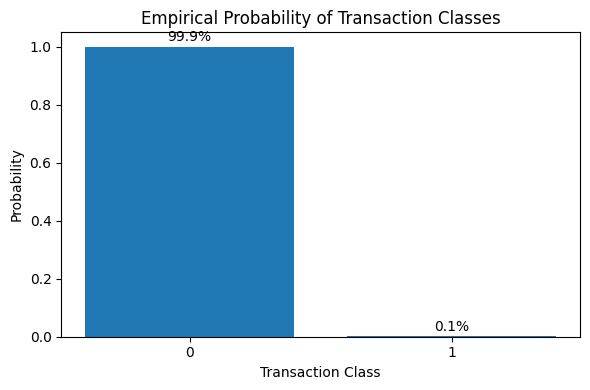

0.0
count    2.000000e+05
mean     8.767864e+03
std      2.240319e+04
min      6.470000e+00
25%      2.157625e+03
50%      6.134160e+03
75%      1.049240e+04
max      2.499708e+06
Name: Amount, dtype: float64
count    2.000000e+05
mean     8.767864e+03
std      2.240319e+04
min      6.470000e+00
50%      6.134160e+03
90%      1.658647e+04
95%      2.207729e+04
99%      4.529289e+04
99.9%    3.492424e+05
max      2.499708e+06
Name: Amount, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


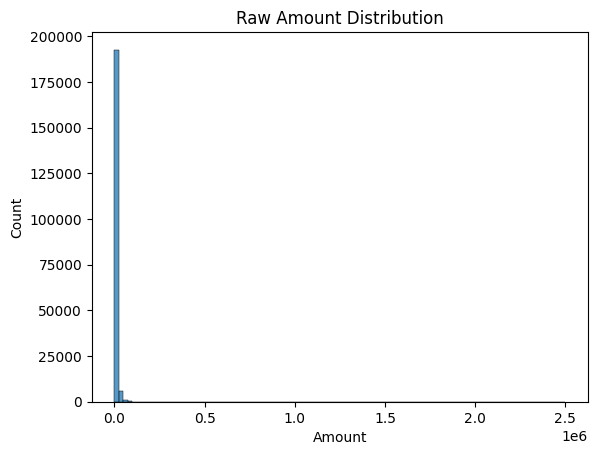

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


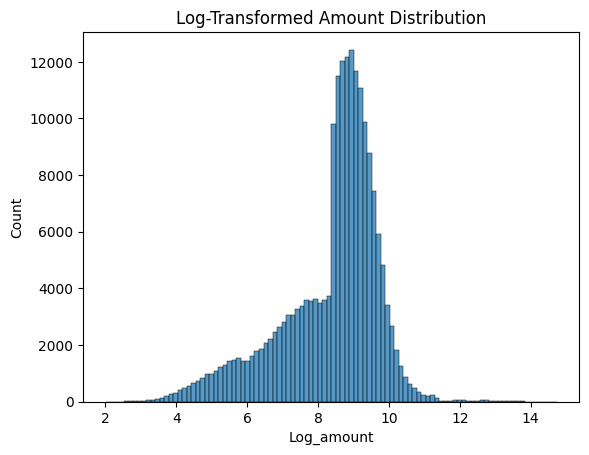

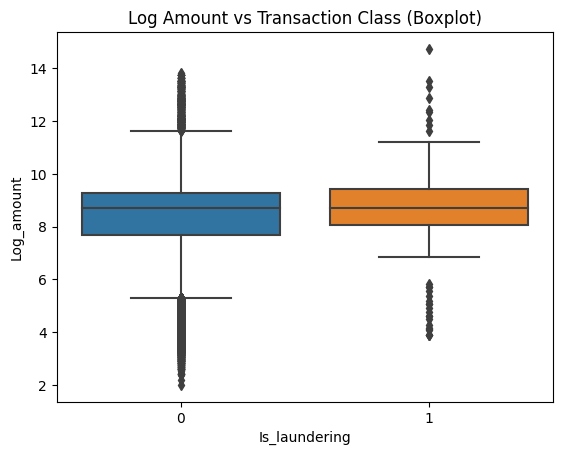

self.cat_cols: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Type of self.cat_cols <class 'list'>
DataFrame dimensions for cat_col (160000, 5)
type(encoded): <class 'scipy.sparse._csr.csr_matrix'>
encoded.shape BEFORE: (160000, 69)
encoded.shape AFTER: (160000, 69)
len(feature_names): 69
first few feature names: ['Payment_currency_Albanian lek' 'Payment_currency_Dirham'
 'Payment_currency_Euro' 'Payment_currency_Indian rupee'
 'Payment_currency_Mexican Peso' 'Payment_currency_Moroccan dirham'
 'Payment_currency_Naira' 'Payment_currency_Pakistani rupee'
 'Payment_currency_Swiss franc' 'Payment_currency_Turkish lira']
self.cat_cols: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Type of self.cat_cols <class 'list'>
DataFrame dimensions for cat_col (40000, 5)
type(encoded): <class 'scipy.sparse._csr.csr_matrix'>
encoded.shape BEFORE: (40000, 69)
encoded.shape AFTER: (

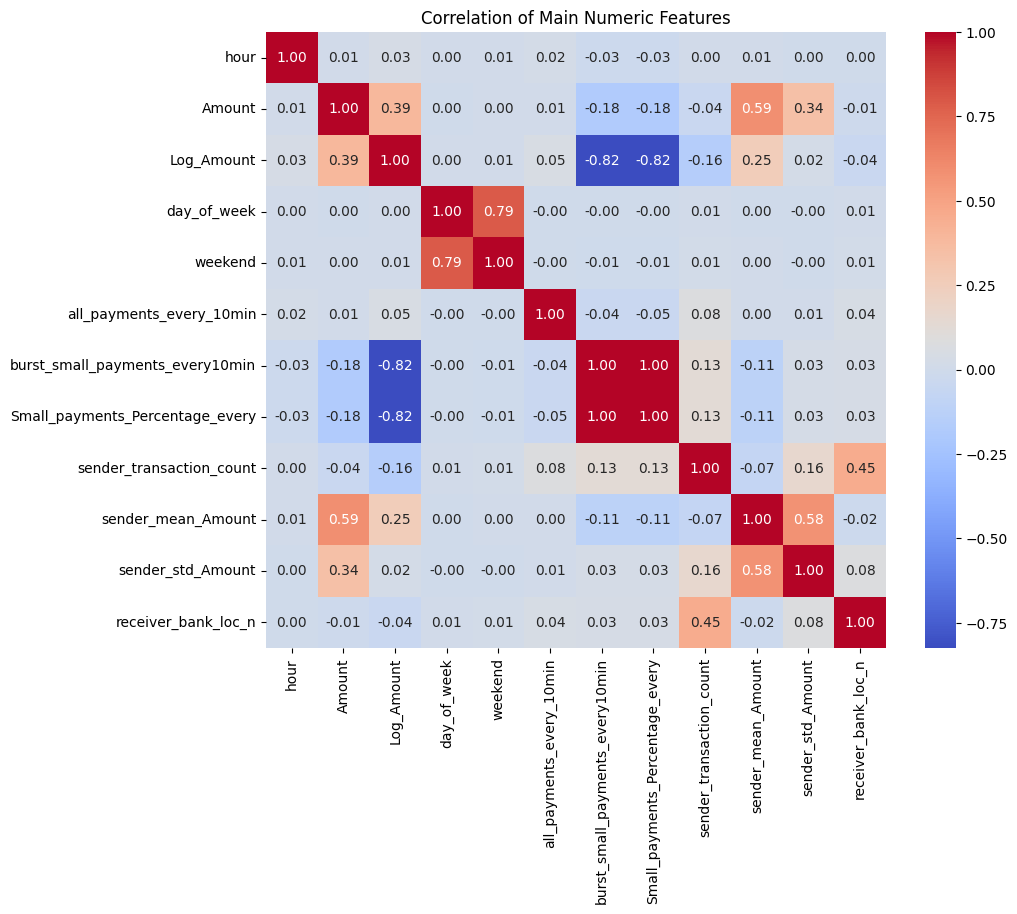


Top correlations with target:
sender_mean_Amount                    0.048619
Amount                                0.035804
Payment_type_Cash Deposit             0.031493
Payment_currency_Mexican Peso         0.019033
Received_currency_UK pounds          -0.018639
Sender_bank_location_Mexico           0.018367
Receiver_bank_location_UK            -0.017332
Payment_type_Cross-border             0.014303
Payment_type_Cash Withdrawal          0.014191
sender_transaction_count             -0.013788
Received_currency_Albanian lek        0.012951
Receiver_bank_location_Italy          0.012230
Receiver_bank_location_Albania        0.011152
Received_currency_Swiss franc         0.010077
Payment_type_Debit card              -0.008661
Payment_type_Cheque                  -0.008614
Receiver_bank_location_India          0.008499
Payment_currency_UK pounds           -0.008203
Receiver_bank_location_Switzerland    0.007910
Received_currency_Indian rupee        0.007485
Sender_bank_location_UK      

In [13]:
def main():
    # -------------------------
    # 1) Load data
    # -------------------------
    path = "/kaggle/input/synthetic-transaction-monitoring-dataset-aml/SAML-D.csv"

    dataset = DataSet()
    df = dataset.dataload(path)

    # -------------------------
    # 2) Overview
    # -------------------------
    overview = DataOverviewer()
    overview.datasetOverview(df)

    explorer = AMLExplorer(df, label_col="Is_laundering")
    explorer.plot_class_distribution()
    explorer.EDA_amount(amount_col="Amount")

    # -------------------------
    # 3) Train / Test split
    # -------------------------
    splitter = DataFrame_Split()
    train_df, test_df = splitter.train_test_split(df)

    # -------------------------
    # 4) Basic feature engineering
    # -------------------------
    fe1 = FeatureEngineering_1()
    train_df, test_df = fe1.new_features(train_df, test_df)

    fe2 = FeatureEngineering_2()
    senderbehaviour = fe2.sendergrouping_eng(train_df)

    train_df = fe2.merging(senderbehaviour, train_df)
    test_df = fe2.merging(senderbehaviour, test_df)

    # -------------------------
    # 5) One-hot encoding
    # -------------------------
    cat_cols = [
        "Payment_currency",
        "Received_currency",
        "Sender_bank_location",
        "Receiver_bank_location",
        "Payment_type"
    ]

    encoder = Encoder(cat_cols=cat_cols)
    encoder.fit(train_df)

    train_df = encoder.transform(train_df)
    test_df = encoder.transform(test_df)

    # -------------------------
    # 6) Time window features
    # -------------------------
    time_features = TimeFeatures()
    train_df, test_df = time_features.burst_transactions(train_df, test_df)

    print(train_df.head(10))
    print(train_df.info())

    # -------------------------
    # 7) Correlation
    # -------------------------
    corr_obj = Correlation()
    corr_obj.corr(train_df)

    # -------------------------
    # 8) Prepare baseline model inputs
    # -------------------------
    label_col = "Is_laundering"
    y_test = test_df[label_col]

    drop_cols = [
        "Is_laundering",
        "Laundering_type",
        "Date",
        "Time",
        "timestamp"
    ]

    X_train_base = train_df.drop(columns=drop_cols, errors="ignore")
    X_test_base = test_df.drop(columns=drop_cols, errors="ignore")

    X_train_base = X_train_base.select_dtypes(include=["number"]).copy()
    X_test_base = X_test_base.select_dtypes(include=["number"]).copy()

    X_train_base = X_train_base.fillna(0)
    X_test_base = X_test_base.fillna(0)

    baseline_features = X_train_base.columns.tolist()

    # -------------------------
    # 9) Baseline model
    # -------------------------
    model = AML_Model(contamination="auto", model_name="baseline")

    results = model.train_evaluation(
        train_df=X_train_base,
        test_df=X_test_base,
        features=baseline_features,
        y_test=y_test
    )

    print("\nFinal Baseline Results:")
    print({k: v for k, v in results.items() if k != "threshold_results"})

    print("\nBaseline Threshold Table:")
    print(results["threshold_results"].round(4).to_string(index=False))

    # -------------------------
    # 10) Prepare modified model inputs
    # -------------------------
    X_train_mod = X_train_base.copy()
    X_test_mod = X_test_base.copy()

    X_train_mod["sender_std_Amount"] = X_train_mod["sender_std_Amount"].fillna(1)
    X_test_mod["sender_std_Amount"] = X_test_mod["sender_std_Amount"].fillna(1)

    X_train_mod.loc[X_train_mod["sender_std_Amount"] < 1e-6, "sender_std_Amount"] = 1
    X_test_mod.loc[X_test_mod["sender_std_Amount"] < 1e-6, "sender_std_Amount"] = 1

    X_train_mod["Amount_zscore"] = (
        (X_train_mod["Amount"] - X_train_mod["sender_mean_Amount"]) / X_train_mod["sender_std_Amount"]
    )
    X_test_mod["Amount_zscore"] = (
        (X_test_mod["Amount"] - X_test_mod["sender_mean_Amount"]) / X_test_mod["sender_std_Amount"]
    )

    X_train_mod = X_train_mod.drop(columns=["Log_Amount"], errors="ignore")
    X_test_mod = X_test_mod.drop(columns=["Log_Amount"], errors="ignore")

    X_train_mod = X_train_mod.replace([np.inf, -np.inf], 0).fillna(0)
    X_test_mod = X_test_mod.replace([np.inf, -np.inf], 0).fillna(0)

    modified_features = X_train_mod.columns.tolist()

    # -------------------------
    # 11) Modified model
    # -------------------------
    model2 = AML_Model(contamination="auto", model_name="modified")

    results2 = model2.train_evaluation(
        train_df=X_train_mod,
        test_df=X_test_mod,
        features=modified_features,
        y_test=y_test
    )

    print("\nFinal Modified Results:")
    print({k: v for k, v in results2.items() if k != "threshold_results"})

    print("\nModified Threshold Table:")
    print(results2["threshold_results"].round(4).to_string(index=False))

    # -------------------------
    # 12) Baseline vs Modified comparison
    # -------------------------
    comparison_df = compare_threshold_tables(results, results2)

    print("\nBaseline vs Modified Comparison:")
    print(comparison_df.round(4).to_string(index=False))


main()